In [ ]:
from torchsummary import summary
import reinforcement
import models
import networks
import gymnasium as gym
import numpy as np
import torch
import ale_py
import time
import utils

In [ ]:
env = gym.make("BipedalWalker-v3", hardcore = False)
s, _ = env.reset()

env.states = env.observation_space.shape[0]
env.actions = env.action_space.shape[0]

actor = models.MLP(env.states, env.actions, softmax=False, tanh=True, lr = 1e-4, hidden_dims = [400, 200])
critic = models.MLP((env.states+env.actions), 1, softmax=False, lr = 1e-3, hidden_dims = [400, 200])

actor.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/1000ep_solve/models/actor_ep1000.pth"))
critic.load_state_dict(torch.load("agents/ddpg/BipedalWalker-v3/1000ep_solve/models/critic_ep1000.pth"))

device = "cuda"
actor.to(device)
critic.to(device)

#rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 1000, verbose=1, checkpoint=50)
rewards, steps, actor_loss, critic_loss = reinforcement.train_ddpg(env, actor, critic, episodes = 100, verbose=1, checkpoint=999, BATCH_SIZE=0)


Episode 0 finished with reward 288.6423645019531 in 892 steps and 3.031537 time, Total steps: 893
Actor loss: 0, Critic loss: 0, Total steps: 893


c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\numpy\_core\fromnumeric.py:3859: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hss19\anaconda3\envs\ml-torch\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Episode 1 finished with reward 289.6643981933594 in 880 steps and 2.799707 time, Total steps: 1774
Actor loss: nan, Critic loss: nan, Total steps: 1774
Episode 2 finished with reward 290.42962646484375 in 874 steps and 2.719582 time, Total steps: 2649
Actor loss: nan, Critic loss: nan, Total steps: 2649
Episode 3 finished with reward 290.296142578125 in 858 steps and 2.550246 time, Total steps: 3508
Actor loss: nan, Critic loss: nan, Total steps: 3508
Episode 4 finished with reward 286.8253479003906 in 909 steps and 2.876653 time, Total steps: 4418
Actor loss: nan, Critic loss: nan, Total steps: 4418
Episode 5 finished with reward 288.68524169921875 in 891 steps and 2.688508 time, Total steps: 5310
Actor loss: nan, Critic loss: nan, Total steps: 5310
Episode 6 finished with reward 290.2335510253906 in 875 steps and 2.838968 time, Total steps: 6186
Actor loss: nan, Critic loss: nan, Total steps: 6186
Episode 7 finished with reward 288.0357360839844 in 882 steps and 2.762833 time, Total 

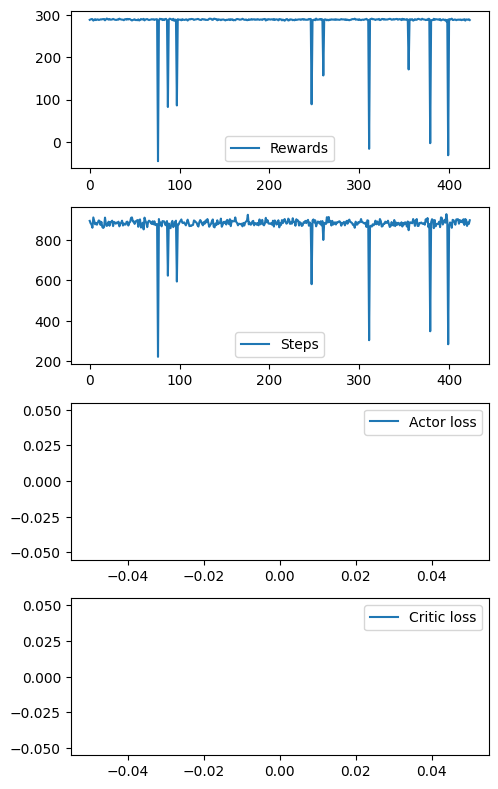

In [ ]:
import matplotlib.pyplot as plt
## Plot the rewards, steps, and errors
fig, ax = plt.subplots(4, figsize=(5, 8))
ax[0].plot(rewards, label='Rewards')
ax[1].plot(steps, label='Steps')
ax[2].plot(actor_loss, label='Actor loss')  
ax[3].plot(critic_loss, label='Critic loss')  

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

print(np.mean(rewards), np.mean(steps))

plt.tight_layout()
plt.show()

In [ ]:


env = gym.make("BipedalWalker-v3", hardcore = 1, render_mode = "rgb_array")

#video_folder = "agents/ddpg/BipedalWalker-v3/2025-06-24_16;52;53/videos"
video_folder = "temp/"
utils.record_model(env, actor, video_folder, "ep1000")

Episode finished. Total reward: -22.521469116210938
